In [13]:
import pandas as pd
import joblib
import numpy as np
import os

TASKS = ['risksensitive', 'twostep', 'hcp', 'mid', 'gonogo']

BASE = "/mnt/scratch/projects/rewardMap/reward_signature/results/"

all_test_scores = []
all_best_models = {}

for task in TASKS:
    task_dir = os.path.join(BASE, task)
    
    # find all subs by listing the files
    sub_files = [f for f in os.listdir(task_dir) if f.startswith("test_scores_sub_")]
    
    for f in sub_files:
        sub = int(f.split("_")[-1].split(".")[0])   # parse subject ID
        
        # --- Load test scores ---
        df = pd.read_csv(os.path.join(task_dir, f))
        df["train_task_label"] = task
        df["subject"] = sub
        all_test_scores.append(df)
        
        # --- Load best model ---
        model_file = os.path.join(task_dir, f"best_model_sub_{sub}.joblib")
        if os.path.exists(model_file):
            best_model = joblib.load(model_file)
            all_best_models[(task, sub)] = best_model

print("Loaded test scores for all tasks/subjects.")
all_test_scores = pd.concat(all_test_scores, ignore_index=True)
        

Loaded test scores for all tasks/subjects.


In [14]:
all_test_scores[all_test_scores.train_task_label == "mid"]

,train_task,test_task,test_subject,class_dist,balanced_acc,macro_f1,train_task_label,subject
200,mid,mid,8,"(array([-1., 0., 1.]), array([0.14, 0.59, 0....",0.496876,0.480586,mid,8
201,mid,risksensitive,8,"(array([0., 1.]), array([0.26, 0.74]))",0.591418,0.346258,mid,8
202,mid,twostep,8,"(array([0., 1.]), array([0.44, 0.56]))",0.567485,0.373938,mid,8
203,mid,hcp,8,"(array([-1., 0., 1.]), array([0.44, 0.12, 0....",0.410714,0.372549,mid,8
204,mid,gonogo,8,"(array([-1., 0., 1.]), array([0.2 , 0.42, 0....",0.475266,0.471987,mid,8
...,...,...,...,...,...,...,...,...
270,mid,mid,12,"(array([-1., 0., 1.]), array([0.13, 0.61, 0....",0.493695,0.448462,mid,12
271,mid,risksensitive,12,"(array([0., 1.]), array([0.38, 0.62]))",0.492857,0.306951,mid,12
272,mid,twostep,12,"(array([0., 1.]), array([0.54, 0.46]))",0.605733,0.405558,mid,12
273,mid,hcp,12,"(array([-1., 0., 1.]), array([0.46, 0.1 , 0....",0.378489,0.319390,mid,12


In [15]:
import pandas as pd

# Filter for models trained on MID
mid_results = all_test_scores[all_test_scores["train_task_label"] == "mid"]

# Group by the *test task* and average across subjects
generalization_mid = (
    mid_results
    .groupby("test_task")[["balanced_acc", "macro_f1"]]
    .mean()
    .reset_index()
    .sort_values("test_task")
)

generalization_mid


,test_task,balanced_acc,macro_f1
0,gonogo,0.455909,0.448230
1,hcp,0.391977,0.306670
2,mid,0.486679,0.436414
3,risksensitive,0.531234,0.319744
4,twostep,0.500215,0.338607


# Averaged accuracies across all subjects

Train task: risksensitive, Test task: risksensitive, Mean: 0.6103, std: 0.0548
Train task: risksensitive, Test task: twostep, Mean: 0.6075, std: 0.0406
Train task: risksensitive, Test task: hcp, Mean: 0.5109, std: 0.0836
Train task: risksensitive, Test task: mid, Mean: 0.5755, std: 0.0461
Train task: risksensitive, Test task: gonogo, Mean: 0.3844, std: 0.0391
Train task: twostep, Test task: risksensitive, Mean: 0.5932, std: 0.0349
Train task: twostep, Test task: twostep, Mean: 0.6166, std: 0.0573
Train task: twostep, Test task: hcp, Mean: 0.53, std: 0.0837
Train task: twostep, Test task: mid, Mean: 0.5809, std: 0.0578
Train task: twostep, Test task: gonogo, Mean: 0.3902, std: 0.0265
Train task: hcp, Test task: risksensitive, Mean: 0.4174, std: 0.0537
Train task: hcp, Test task: twostep, Mean: 0.4362, std: 0.082
Train task: hcp, Test task: hcp, Mean: 0.4943, std: 0.0903
Train task: hcp, Test task: mid, Mean: 0.4278, std: 0.0502
Train task: hcp, Test task: gonogo, Mean: 0.481, std: 0.055

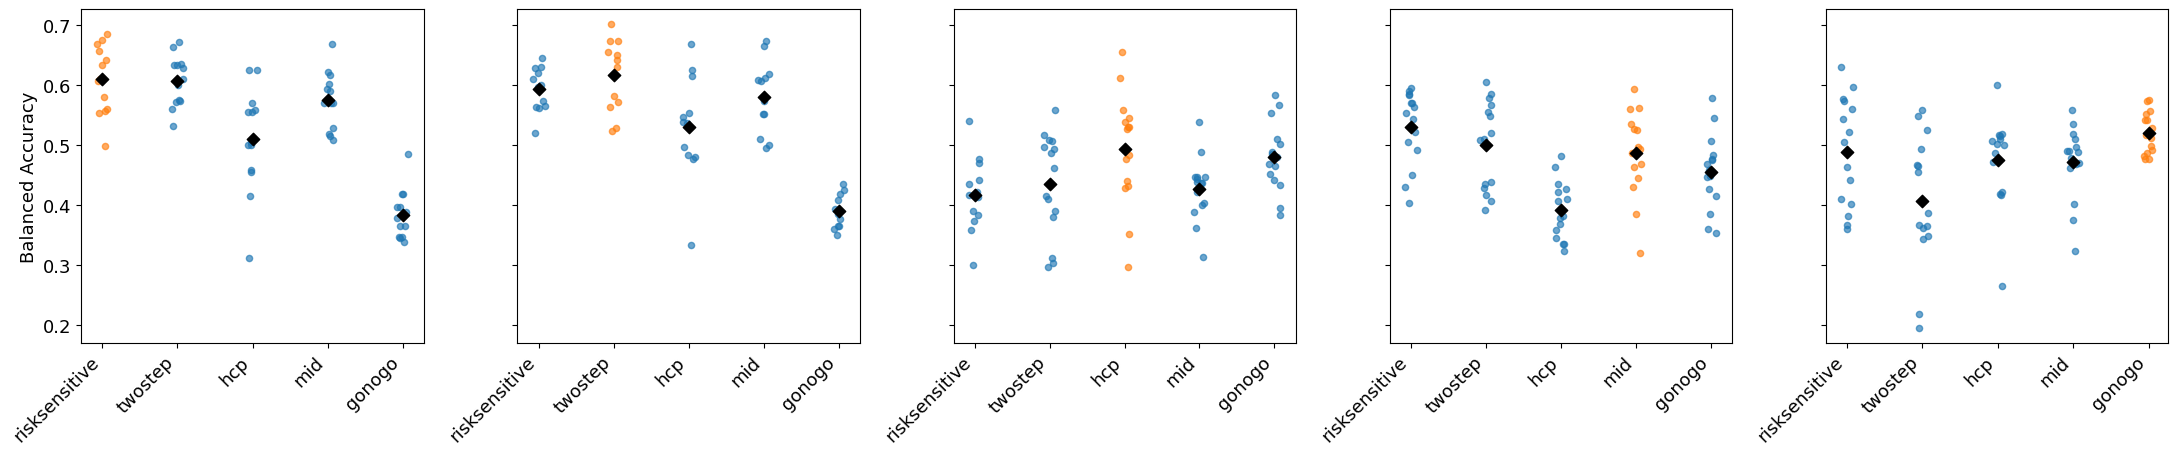

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.size": 13,       # Default font size
})

TASKS = ['risksensitive', 'twostep', 'hcp', 'mid', 'gonogo']

COLOR_OTHER = "#1f77b4"   # blue
COLOR_SELF  = "#ff7f0e"   # orange
MEAN_COLOR  = "black"
JITTER = 0.08

# Create figure
fig, axes = plt.subplots(1, len(TASKS), figsize=(22, 5), sharey=True)

for i, train_task in enumerate(TASKS):
    
    ax = axes[i]
    
    # Select all rows where this task was used for training
    df = all_test_scores[all_test_scores["train_task_label"] == train_task]

    # Loop through test tasks
    for j, test_task in enumerate(TASKS):
        # Extract all subject scores for this (train,test) pair
        vals = df[df["test_task"] == test_task]["balanced_acc"].values
        
        # Color depending on same-task or other-task
        color = COLOR_SELF if test_task == train_task else COLOR_OTHER
        
        # X-locations (j + jitter)
        x_jittered = j + np.random.uniform(-JITTER, JITTER, size=len(vals))
        
        # Individual subject points
        ax.scatter(x_jittered, vals, color=color, alpha=0.65, s=20)
        
        # Mean marker
        mean_val = np.round(np.mean(vals), 4)
        std = np.round(np.std(vals), 4)
        print(f"Train task: {train_task}, Test task: {test_task}, Mean: {mean_val}, std: {std}")
        ax.scatter(j, mean_val, color=MEAN_COLOR, s=40, marker="D", zorder=5)

    # Formatting
    ax.set_xticks(range(len(TASKS)))
    ax.set_xticklabels(TASKS, rotation=45, ha="right")

    if i == 0:
        ax.set_ylabel("Balanced Accuracy")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Train task: risksensitive, Test task: risksensitive, Mean: 0.5681, std: 0.0697
Train task: risksensitive, Test task: twostep, Mean: 0.593, std: 0.0483
Train task: risksensitive, Test task: hcp, Mean: 0.4527, std: 0.0948
Train task: risksensitive, Test task: mid, Mean: 0.533, std: 0.0663
Train task: risksensitive, Test task: gonogo, Mean: 0.3317, std: 0.0383
Train task: twostep, Test task: risksensitive, Mean: 0.5841, std: 0.0381
Train task: twostep, Test task: twostep, Mean: 0.5971, std: 0.0638
Train task: twostep, Test task: hcp, Mean: 0.4548, std: 0.1422
Train task: twostep, Test task: mid, Mean: 0.5136, std: 0.1001
Train task: twostep, Test task: gonogo, Mean: 0.341, std: 0.0222
Train task: hcp, Test task: risksensitive, Mean: 0.2853, std: 0.051
Train task: hcp, Test task: twostep, Mean: 0.3117, std: 0.0466
Train task: hcp, Test task: hcp, Mean: 0.4528, std: 0.0961
Train task: hcp, Test task: mid, Mean: 0.3654, std: 0.0555
Train task: hcp, Test task: gonogo, Mean: 0.4323, std: 0.056

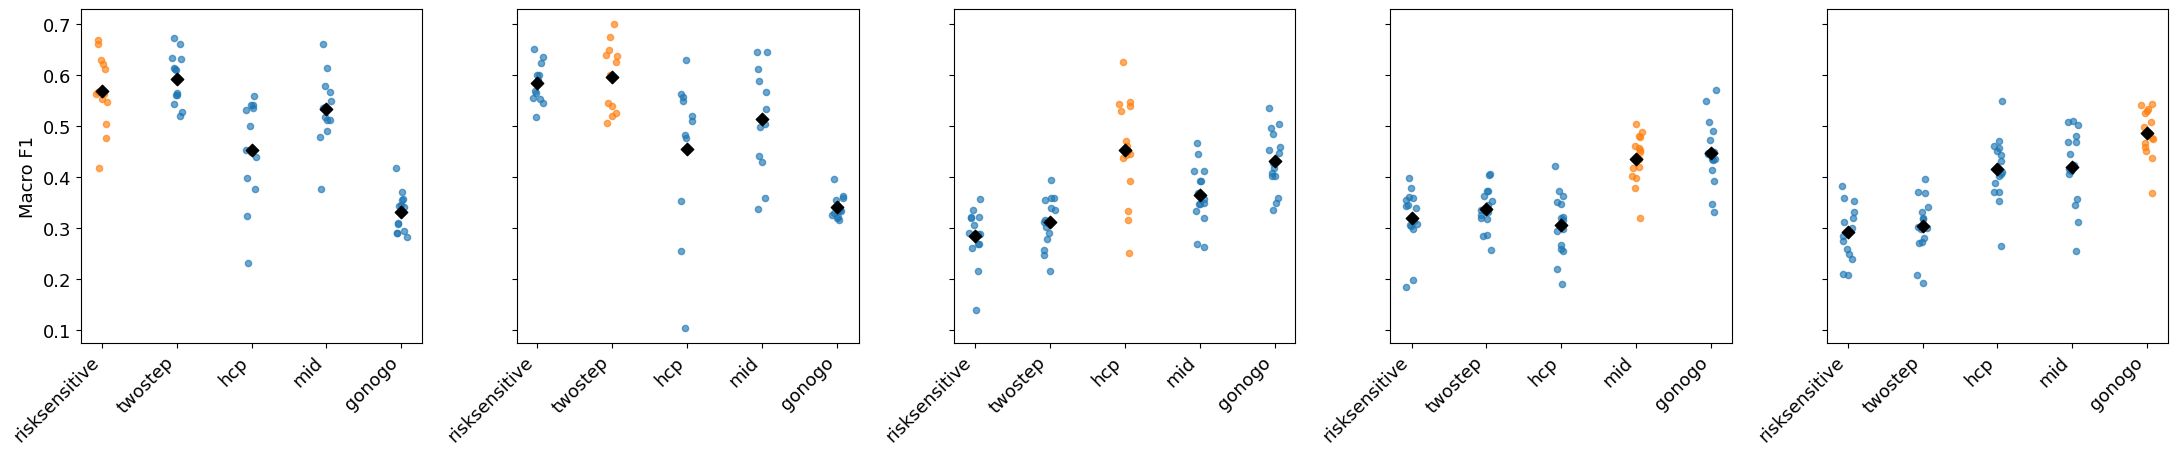

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TASKS = ['risksensitive', 'twostep', 'hcp', 'mid', 'gonogo']

COLOR_OTHER = "#1f77b4"   # blue
COLOR_SELF  = "#ff7f0e"   # orange
MEAN_COLOR  = "black"
JITTER = 0.08

# Create figure
fig, axes = plt.subplots(1, len(TASKS), figsize=(22, 5), sharey=True)

for i, train_task in enumerate(TASKS):
    
    ax = axes[i]
    
    # Select all rows where this task was used for training
    df = all_test_scores[all_test_scores["train_task_label"] == train_task]

    # Loop through test tasks
    for j, test_task in enumerate(TASKS):
        # Extract all subject scores for this (train,test) pair
        vals = df[df["test_task"] == test_task]["macro_f1"].values
        
        # Color depending on same-task or other-task
        color = COLOR_SELF if test_task == train_task else COLOR_OTHER
        
        # X-locations (j + jitter)
        x_jittered = j + np.random.uniform(-JITTER, JITTER, size=len(vals))
        
        # Individual subject points
        ax.scatter(x_jittered, vals, color=color, alpha=0.65, s=20)
        
        # Mean marker
        mean_val = np.round(np.mean(vals), 4)
        std = np.round(np.std(vals), 4)
        print(f"Train task: {train_task}, Test task: {test_task}, Mean: {mean_val}, std: {std}")
        ax.scatter(j, mean_val, color=MEAN_COLOR, s=40, marker="D", zorder=5)

    # Formatting
    ax.set_xticks(range(len(TASKS)))
    ax.set_xticklabels(TASKS, rotation=45, ha="right")

    if i == 0:
        ax.set_ylabel("Macro F1")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# TDOD indicate baseline performance with horizontal line

## Confusion matrices

In [6]:
import os
import numpy as np
import pandas as pd
import joblib

# Path to the results directory
results_dir = "/mnt/scratch/projects/rewardMap/reward_signature/nested_results/"


# List of tasks
TASKS = ['risksensitive', 'twostep', 'hcp', 'mid', 'gonogo']

# Dictionaries to hold all data
all_data = {}
all_test_scores = {}
all_inner_cv = {}
all_models = {}

for task in TASKS:
    task_dir = os.path.join(results_dir, task)
    
    # Skip if directory does not exist
    if not os.path.exists(task_dir):
        continue
    
    # Find all subjects in the task folder
    sub_files = [f for f in os.listdir(task_dir) if f.startswith("data_sub") and f.endswith(".npz")]
    
    all_data[task] = {}
    all_test_scores[task] = {}
    all_inner_cv[task] = {}
    all_models[task] = {}
    
    for file in sub_files:
        sub = file.split("sub")[1].split(".npz")[0]  # extract subject id
        # Load the NPZ data
        npz_path = os.path.join(task_dir, file)
        npz_data = np.load(npz_path, allow_pickle=True)
        all_data[task][sub] = {
            "X": npz_data["X"],
            "Y": npz_data["Y"],
            "Y_signed": npz_data["Y_signed"],
            "trial_types": npz_data["trial_types"],
            "index_ranges": npz_data["index_ranges"],
            "train_splits": npz_data["train_splits"],
            "test_splits": npz_data["test_splits"],
        }

        # Load test scores CSV
        test_scores_path = os.path.join(task_dir, f"test_scores_sub_{sub}.csv")
        if os.path.exists(test_scores_path):
            all_test_scores[task][sub] = pd.read_csv(test_scores_path)

        # Load inner CV results CSV
        inner_cv_path = os.path.join(task_dir, f"inner_cv_results_sub_{sub}.csv")
        if os.path.exists(inner_cv_path):
            all_inner_cv[task][sub] = pd.read_csv(inner_cv_path)

        # Load saved model
        model_path = os.path.join(task_dir, f"best_model_sub_{sub}.joblib")
        if os.path.exists(model_path):
            all_models[task][sub] = joblib.load(model_path)

print("All data loaded successfully!")


KeyboardInterrupt: 

In [ ]:
all_data

{}

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example: true labels and predictions
Y_test = all_data['risksensitive']['01']['Y_signed']  # adjust task/subject
y_pred = all_models['risksensitive']['01']['model'].predict(
    all_data['risksensitive']['01']['X'][all_data['risksensitive']['01']['test_splits']['risksensitive']['01']]
)

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(Y_test))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


KeyError: 'risksensitive'

NameError: name 'X' is not defined